# 태깅 관련 분석

## 라이브러리 및 DB커넥션

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [2]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
import requests
import json

In [4]:
host = 'localhost'
port = '3306'
user = 'root'
password = '1221'
database = 'LOL_data'

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

## 태깅을 위한 분석

### 공식 문서 ddragon에서 속성 확인

In [7]:
tagdict = {
    '진': ['AD', '포킹',],
    '질리언': ['유틸', '포킹',],
    '징크스': ['AD', '지속딜', '글로벌',],
    '초가스': ['CC', ],
    '카르마': ['AP', '포킹',],
    '카밀': ['AD', '돌진', '스플릿 푸쉬',],
    '카사딘': ['AP', 'Anti AP', '이동기', ],
    '카서스': ['AP', '광역 데미지', '지속딜', '글로벌', ],
    '카시오페아': ['AP', '지속딜', ],
    '카이사': ['hybrid', '포킹', '지속딜', '은신',],
    '카직스': ['AD', '이동기', '은신',],
    '카타리나': ['hybrid', '이동기', '광역 데미지',],
    '칼리스타': ['AD', '지속딜', '이동기', ],
    '케넨': ['AP', '돌진', '광역 데미지',],
    '케이틀린': ['AD', ],
    '케인': ['AD', '돌진', '이동기',],
    '케일': ['hybrid', '지속딜', ],
    '코그모': ['hybrid', '포킹', '지속딜', ],
    '코르키': ['AD', '포킹', '이동기',],
    '퀸': ['AD', '스플릿 푸쉬', '이동기',],
    '크산테': ['CC', '돌진', '이동기',],
    '클레드': ['AD', '돌진', '글로벌',],
    '키아나': ['AD', '돌진', '은신',],
    '킨드레드': ['AD', '지속딜', ],
    '타릭': ['유틸', ],
    '탈론': ['AD', '이동기', '은신',],
    '탈리야': ['AP', '스플릿 푸쉬', '지속딜', '글로벌',],
    '탐 켄치': ['유틸', '이동기',],
    '트런들': ['AD', '스플릿 푸쉬', '지속딜',],
    '트리스타나': ['AD', '이동기',],
    '트린다미어': ['AD', '돌진', '스플릿 푸쉬', '이동기',],
    '트위스티드 페이트': ['AP', '스플릿 푸쉬', '글로벌',],
    '트위치': ['AD', '지속딜', '은신',],
    '티모': ['AP', '스플릿 푸쉬', '은신',],
    '파이크': ['AD', '그랩', '은신', ],
    '판테온': ['AD', '스플릿 푸쉬', '글로벌',],
    '피들스틱': ['CC', '광역 데미지',],
    '피오라': ['AD', '스플릿 푸쉬',],
    '피즈': ['AP', '돌진', '이동기',],
    '하이머딩거': ['AP', '스플릿 푸쉬', '지속딜',],
    '헤카림': ['AD', '돌진',],
    '흐웨이': ['AP', '포킹',],
}

In [25]:
CHAMPION_LIST_URL = "https://ddragon.leagueoflegends.com/cdn/{version}/data/{language}/champion.json"

# URL 생성
url = CHAMPION_LIST_URL.format(version='14.21.1', language='ko_KR')

# 챔피언 목록 요청
response = requests.get(url)
champion_list = response.json()

# 챔피언 이름 출력
champinfolist = []
for champ in champion_list["data"]:
    name = champion_list['data'][champ]['name']
    if name in tagdict.keys():
        champ_url = "https://ddragon.leagueoflegends.com/cdn/{version}/data/{language}/champion/{champion}.json"
        url = BASE_URL.format(version='14.21.1', language='ko_KR', champion=champ)
        response = requests.get(url)
        champion = response.json()
        
        spells = champion['data'][champ]['spells']
        champinfo = [(name, champ), ]
        for spell in spells:
            champinfo.append(f'{spell['name']}: {spell['range']} / {spell['rangeBurn']}')
        champinfolist.append(champinfo)

for champinfo in sorted(champinfolist, key=lambda x: x[0]):
    for skill in champinfo:
        print(skill)

('진', 'Jhin')
춤추는 유탄: [550, 550, 550, 550, 550] / 550
살상연희: [3000, 3000, 3000, 3000, 3000] / 3000
강제 관람: [750, 750, 750, 750, 750] / 750
커튼 콜: [25000, 25000, 25000] / 25000
('질리언', 'Zilean')
시한 폭탄: [900, 900, 900, 900, 900] / 900
되감기: [600, 600, 600, 600, 600] / 600
시간 왜곡: [550, 550, 550, 550, 550] / 550
시간 역행: [900, 900, 900] / 900
('징크스', 'Jinx')
휘릭휘릭!: [600, 600, 600, 600, 600] / 600
빠직!: [1450, 1450, 1450, 1450, 1450] / 1450
와작와작 뻥!: [925, 925, 925, 925, 925] / 925
초강력 초토화 로켓!: [25000, 25000, 25000] / 25000
('초가스', 'Chogath')
파열: [950, 950, 950, 950, 950] / 950
흉포한 울부짖음: [300, 300, 300, 300, 300] / 300
날카로운 가시: [40, 40, 40, 40, 40] / 40
포식: [175, 175, 175] / 175
('카르마', 'Karma')
내면의 열정: [950, 950, 950, 950, 950] / 950
굳은 결의: [675, 675, 675, 675, 675] / 675
고무: [800, 800, 800, 800, 800] / 800
만트라: [1100, 1100, 1100, 1100] / 1100
('카밀', 'Camille')
정확성 프로토콜: [325, 325, 325, 325, 325] / 325
전술적 휩쓸기: [610, 610, 610, 610, 610] / 610
갈고리 발사: [800, 800, 800, 800, 800] / 800
마법공학 최후통첩: [475

In [23]:
champion_list['data'].keys()

dict_keys(['Aatrox', 'Ahri', 'Akali', 'Akshan', 'Alistar', 'Amumu', 'Anivia', 'Annie', 'Aphelios', 'Ashe', 'AurelionSol', 'Aurora', 'Azir', 'Bard', 'Belveth', 'Blitzcrank', 'Brand', 'Braum', 'Briar', 'Caitlyn', 'Camille', 'Cassiopeia', 'Chogath', 'Corki', 'Darius', 'Diana', 'Draven', 'DrMundo', 'Ekko', 'Elise', 'Evelynn', 'Ezreal', 'Fiddlesticks', 'Fiora', 'Fizz', 'Galio', 'Gangplank', 'Garen', 'Gnar', 'Gragas', 'Graves', 'Gwen', 'Hecarim', 'Heimerdinger', 'Hwei', 'Illaoi', 'Irelia', 'Ivern', 'Janna', 'JarvanIV', 'Jax', 'Jayce', 'Jhin', 'Jinx', 'Kaisa', 'Kalista', 'Karma', 'Karthus', 'Kassadin', 'Katarina', 'Kayle', 'Kayn', 'Kennen', 'Khazix', 'Kindred', 'Kled', 'KogMaw', 'KSante', 'Leblanc', 'LeeSin', 'Leona', 'Lillia', 'Lissandra', 'Lucian', 'Lulu', 'Lux', 'Malphite', 'Malzahar', 'Maokai', 'MasterYi', 'Milio', 'MissFortune', 'MonkeyKing', 'Mordekaiser', 'Morgana', 'Naafiri', 'Nami', 'Nasus', 'Nautilus', 'Neeko', 'Nidalee', 'Nilah', 'Nocturne', 'Nunu', 'Olaf', 'Orianna', 'Ornn', 'Pant

### 스플릿 푸쉬 태깅

#### 챔프 별 게임 당 평균 사이드 포탑 파괴 횟수 확인

In [9]:
query = '''with BK_event_cnt as (
	select cp.match_id, champion_id, sum(if(bk.match_id is null, 0, 1)) as count
	from (select match_id, participant_id, building_type, line_type
		from building_kill
		where line_type != 'MID_LANE' and timestamp >= 60000 * 15) bk
	right join champion_participant_id cp on bk.match_id = cp.match_id and bk.participant_id = cp.participant_id
	group by 1, 2
)
select cd.champion_id, champion_name, avg(count) as avg_bk_per_game
from BK_event_cnt bk join champion_dict cd on bk.champion_id = cd.champion_id
group by 1 order by 3 desc;'''

In [11]:
meanbk = pd.read_sql(query, engine)

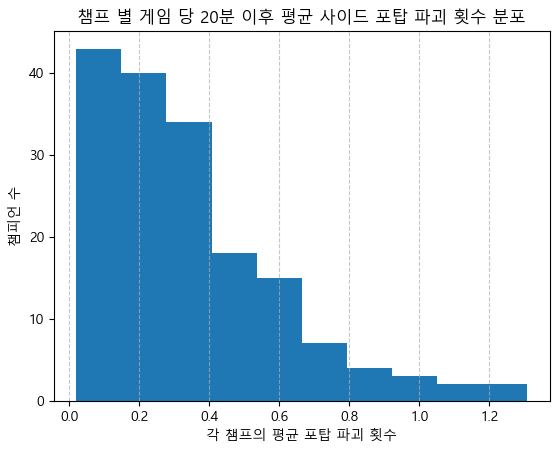

In [12]:
plt.hist(meanbk['avg_bk_per_game'])
plt.title('챔프 별 게임 당 20분 이후 평균 사이드 포탑 파괴 횟수 분포')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlabel('각 챔프의 평균 포탑 파괴 횟수')
plt.ylabel('챔피언 수')
plt.show()

In [13]:
meanbk['avg_bk_per_game'].describe()

count    168.000000
mean       0.338295
std        0.255047
min        0.019400
25%        0.141000
50%        0.278450
75%        0.434925
max        1.308200
Name: avg_bk_per_game, dtype: float64

#### 챔프 별 게임 당 20분 이후 평균 솔로킬 횟수 확인

In [14]:
query = '''with Kill_event_cnt as (
	select cp.match_id, champion_id, sum(if(k.match_id is null, 0, 1)) as count
	from (select match_id, participant_id
		from champion_kill
		where `timestamp` >= 20 * 60000 and assist_id is null) k
	right join champion_participant_id cp on k.match_id = cp.match_id and k.participant_id = cp.participant_id
	group by 1, 2
)
select cd.champion_id, champion_name, avg(count) as avg_kill_per_game
from Kill_event_cnt k join champion_dict cd on k.champion_id = cd.champion_id
group by 1 order by 3 desc;'''

In [15]:
meank = pd.read_sql(query, engine)

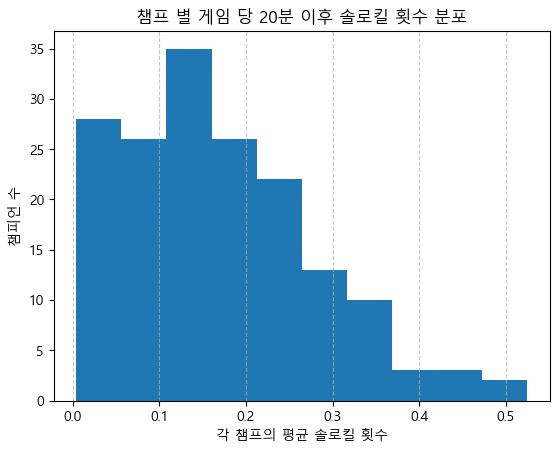

In [16]:
plt.hist(meank['avg_kill_per_game'])
plt.title('챔프 별 게임 당 20분 이후 솔로킬 횟수 분포')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlabel('각 챔프의 평균 솔로킬 횟수')
plt.ylabel('챔피언 수')
plt.show()

In [17]:
meank['avg_kill_per_game'].describe()

count    168.000000
mean       0.166314
std        0.111721
min        0.004100
25%        0.083225
50%        0.144300
75%        0.229525
max        0.524700
Name: avg_kill_per_game, dtype: float64

#### 사이드 포탑 파괴 횟수 평균이 0.75 이상, 20분 이후 솔로킬 횟수 평균이 0.3 이상인 챔피언들로 논리 연산 필터링을 해 보자.

In [39]:
topbk = meanbk[meanbk['avg_bk_per_game'] >= 0.7]['champion_name']

In [41]:
topk = meank[meank['avg_kill_per_game'] >= 0.25]['champion_name']

* AND 연산

In [43]:
champs = []
for k in list(topk):
    if k in list(topbk): champs.append(k)

print(f'챔프 수: {len(champs)}')
for champ in sorted(champs):
    print(champ)

del champs

챔프 수: 11
가렌
그웬
세트
아지르
올라프
요릭
우르곳
일라오이
제이스
트린다미어
피오라


* OR 연산

In [45]:
champs = []
for champ in sorted(list(set(list(topk) + list(topbk)))):
    champs.append(champ)

print(f'챔프 수: {len(champs)}')
for champ in champs:
    print(champ)

del champs

챔프 수: 39
가렌
갱플랭크
그웬
나서스
나피리
렝가
르블랑
리븐
모데카이저
문도 박사
빅토르
세트
신드라
아지르
아칼리
아크샨
올라프
요네
요릭
우르곳
이렐리아
이블린
일라오이
잭스
제드
제이스
카사딘
카직스
카타리나
케넨
케인
퀸
클레드
키아나
탈론
트런들
트린다미어
피오라
피즈


#### 스플릿 푸쉬 포인트(SP Point) 계산

* 단순한 필터링 방식이 아닌, 두 지표의 크기를 적절히 고려하기 위해 두 지표에 MinMax스케일링 후 곱한 SP Point를 기준으로 정해보자.

In [18]:
meanbk['scaled_bk'] = meanbk['avg_bk_per_game']\
    .map(lambda x: (x - min(meanbk['avg_bk_per_game'])) / (max(meanbk['avg_bk_per_game']) - min(meanbk['avg_bk_per_game'])))

In [19]:
meank['scaled_kill'] = meank['avg_kill_per_game']\
    .map(lambda x: (x - min(meank['avg_kill_per_game'])) / (max(meank['avg_kill_per_game']) - min(meank['avg_kill_per_game'])))

In [20]:
sp = meank.merge(meanbk, on=['champion_id', 'champion_name'])
sp['sp_point'] = sp.apply(lambda x: x['scaled_bk'] * x['scaled_kill'], axis=1)

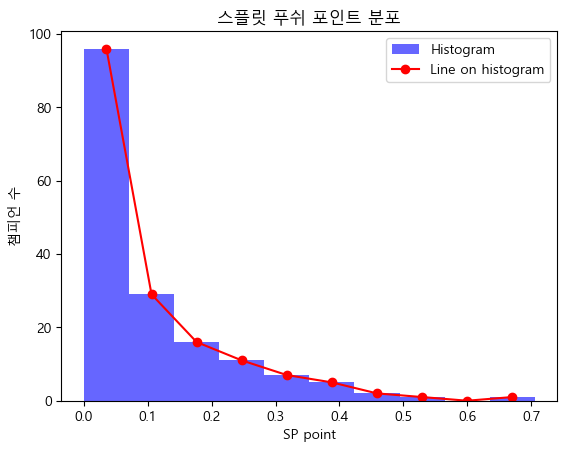

In [21]:
data = sp['sp_point']
bins = 10  # 구간 수
counts, bin_edges = np.histogram(data, bins=bins, density=False)  # 히스토그램 데이터 계산
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # 각 구간의 중앙값

# 히스토그램 그리기
plt.hist(data, bins=bins, alpha=0.6, color='blue', label="Histogram")

# 선 그래프 추가
plt.plot(bin_centers, counts, '-o', color='red', label="Line on histogram")

# 그래프 꾸미기
plt.title("스플릿 푸쉬 포인트 분포")
plt.xlabel('SP point')
plt.ylabel('챔피언 수')
plt.legend()

# 그래프 출력
plt.show()

In [22]:
sp['sp_point'].describe()

count    168.000000
mean       0.103383
std        0.120907
min        0.000000
25%        0.020941
50%        0.055532
75%        0.152072
max        0.705954
Name: sp_point, dtype: float64

In [43]:
sp['sp_point'].quantile([0.2, 0.8])

0.2    0.011754
0.8    0.181129
Name: sp_point, dtype: float64

히스토그램 상 기울기가 두 번째로 가파른 지점인 0.2를 기준으로 구분해보자.  
즉, SP Point가 0.2 이상인 챔피언들은 스플릿 푸쉬 챔피언이다.

In [223]:
sp_champs = sp[sp['sp_point'] >= 0.2].sort_values(by='champion_name').reset_index()[['champion_name', 'sp_point']]
sp_champs

,champion_name,sp_point
0,가렌,0.408019
1,갱플랭크,0.312312
2,그웬,0.431428
3,나서스,0.283262
4,나피리,0.209928
5,렝가,0.275467
6,리븐,0.263716
7,모데카이저,0.231427
8,문도 박사,0.206502
9,세트,0.324067


In [229]:
sp_champs.sort_values(by='sp_point', ascending=False)['champion_name'].values

array(['피오라', '트린다미어', '일라오이', '그웬', '퀸', '가렌', '트런들', '요릭', '우르곳', '세트',
       '갱플랭크', '카사딘', '잭스', '제이스', '아지르', '나서스', '렝가', '올라프', '리븐', '제드',
       '탈론', '이렐리아', '아칼리', '모데카이저', '클레드', '카밀', '요네', '피즈', '나피리',
       '문도 박사'], dtype=object)

In [235]:
'''
'피오라', '트린다미어', '일라오이', '그웬', '퀸', '가렌', '트런들', '요릭', '우르곳', '세트',\
'갱플랭크', '카사딘', '잭스', '제이스', '아지르', '나서스', '렝가', '올라프', '리븐', '제드',\
'탈론', '이렐리아', '아칼리', '모데카이저', '클레드', '카밀', '요네', '피즈', '나피리',\
'문도 박사'
'''.replace('\'', '')

'\n피오라, 트린다미어, 일라오이, 그웬, 퀸, 가렌, 트런들, 요릭, 우르곳, 세트,갱플랭크, 카사딘, 잭스, 제이스, 아지르, 나서스, 렝가, 올라프, 리븐, 제드,탈론, 이렐리아, 아칼리, 모데카이저, 클레드, 카밀, 요네, 피즈, 나피리,문도 박사\n'

### 태깅 사항 DB에 반영하기

In [73]:
cd = pd.read_csv('최종-riotAPI/챔프태그.csv')
cd_edited = pd.read_csv('최종-riotAPI/챔프_포킹_광역_글로벌.csv')

In [79]:
cd['포킹'] = cd_edited['포킹']
cd['광역'] = cd_edited['광역']
cd['글로벌'] = cd_edited['글로벌']

In [83]:
cd = cd.drop(['antiAP', 'antiAD'], axis=1).fillna(0)
cd 

,key,name,전사,암살자,마법사,원거리 공격,지원가,탱커,AP,AD,...,유틸,돌진,포킹,광역,스플릿 푸쉬,글로벌,이동기,은신,버프,그랩
0,86.0,가렌,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0,0,1.0,0,0.0,0.0,0.0,0.0
1,3.0,갈리오,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0,0,0.0,1,1.0,0.0,0.0,0.0
2,41.0,갱플랭크,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1,1,1.0,1,0.0,0.0,0.0,0.0
3,79.0,그라가스,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0,1,0.0,0,1.0,0.0,0.0,0.0
4,104.0,그레이브즈,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0,0,0.0,0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,105.0,피즈,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0,1,0.0,0,1.0,0.0,0.0,0.0
165,74.0,하이머딩거,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1,0,0.0,0,0.0,0.0,0.0,0.0
166,120.0,헤카림,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0,1,0.0,0,1.0,0.0,0.0,0.0
167,910.0,흐웨이,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1,1,0.0,0,0.0,0.0,1.0,0.0


In [85]:
cd = cd.loc[:167]

In [127]:
cd.loc[:, '스플릿 푸쉬'] = cd.apply(lambda x: 1 if x['name'] in sp_champs['champion_name'].values else 0, axis=1)

In [129]:
cd

,key,name,전사,암살자,마법사,원거리 공격,지원가,탱커,AP,AD,...,유틸,돌진,포킹,광역,스플릿 푸쉬,글로벌,이동기,은신,버프,그랩
0,86.0,가렌,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0,0,1,0,0.0,0.0,0.0,0.0
1,3.0,갈리오,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0,0,0,1,1.0,0.0,0.0,0.0
2,41.0,갱플랭크,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1,1,1,1,0.0,0.0,0.0,0.0
3,79.0,그라가스,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0,1,0,0,1.0,0.0,0.0,0.0
4,104.0,그레이브즈,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0,0,0,0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,114.0,피오라,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0,0,1,0,1.0,0.0,0.0,0.0
164,105.0,피즈,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0,1,1,0,1.0,0.0,0.0,0.0
165,74.0,하이머딩거,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1,0,0,0,0.0,0.0,0.0,0.0
166,120.0,헤카림,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0,1,0,0,1.0,0.0,0.0,0.0


In [131]:
def get_tags(row):
    tags = []
    for tag in row.drop(['key', 'name']).index:
        if row[tag] >= 0.5: tags.append(tag)

    return tags

In [133]:
cd.loc[:, 'tags'] = cd.apply(get_tags, axis=1)
cd = cd[['key', 'name', 'tags']]
cd

C:\Users\건\AppData\Local\Temp\ipykernel_30364\3448380305.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cd.loc[:, 'tags'] = cd.apply(get_tags, axis=1)


,key,name,tags
0,86.0,가렌,"[전사, 탱커, AD, 돌진, 스플릿 푸쉬]"
1,3.0,갈리오,"[마법사, 탱커, CC, 글로벌, 이동기]"
2,41.0,갱플랭크,"[전사, AD, 포킹, 광역, 스플릿 푸쉬, 글로벌]"
3,79.0,그라가스,"[전사, 마법사, AP, 광역, 이동기]"
4,104.0,그레이브즈,"[원거리 공격, AD, 이동기]"
...,...,...,...
163,114.0,피오라,"[전사, 암살자, AD, 스플릿 푸쉬, 이동기]"
164,105.0,피즈,"[전사, 암살자, AP, 돌진, 광역, 스플릿 푸쉬, 이동기]"
165,74.0,하이머딩거,"[마법사, 지원가, AP, 포킹]"
166,120.0,헤카림,"[전사, 탱커, AD, 돌진, 광역, 이동기]"


In [135]:
cd = cd.rename({
    'key': 'champion_id',
    'name': 'champion_name'},
           axis=1)\
    .set_index('champion_id')
cd.index = cd.index.astype('int16')
cd['tags'] = cd['tags'].astype('str')
cd.to_sql('champion_dict', engine, if_exists='replace')

168

In [139]:
lt = pd.read_csv('최종-riotAPI/lanetype.csv')
lt

,match_id,participant_id,champion_id,individual_position,team_position,role,lane
0,KR_7346623650,1,901,TOP,TOP,SUPPORT,NONE
1,KR_7346623650,2,72,JUNGLE,JUNGLE,SUPPORT,NONE
2,KR_7346623650,3,517,MIDDLE,MIDDLE,SUPPORT,NONE
3,KR_7346623650,4,81,BOTTOM,BOTTOM,SUPPORT,NONE
4,KR_7346623650,5,44,UTILITY,UTILITY,SUPPORT,NONE
...,...,...,...,...,...,...,...
598255,KR_7332867487,6,122,TOP,TOP,CARRY,TOP
598256,KR_7332867487,7,234,JUNGLE,JUNGLE,NONE,JUNGLE
598257,KR_7332867487,8,84,MIDDLE,MIDDLE,SOLO,MIDDLE
598258,KR_7332867487,9,360,BOTTOM,BOTTOM,SOLO,BOTTOM


In [141]:
lt['match_id'] = lt['match_id'].map(lambda x: x.split('_')[-1])
lt

,match_id,participant_id,champion_id,individual_position,team_position,role,lane
0,7346623650,1,901,TOP,TOP,SUPPORT,NONE
1,7346623650,2,72,JUNGLE,JUNGLE,SUPPORT,NONE
2,7346623650,3,517,MIDDLE,MIDDLE,SUPPORT,NONE
3,7346623650,4,81,BOTTOM,BOTTOM,SUPPORT,NONE
4,7346623650,5,44,UTILITY,UTILITY,SUPPORT,NONE
...,...,...,...,...,...,...,...
598255,7332867487,6,122,TOP,TOP,CARRY,TOP
598256,7332867487,7,234,JUNGLE,JUNGLE,NONE,JUNGLE
598257,7332867487,8,84,MIDDLE,MIDDLE,SOLO,MIDDLE
598258,7332867487,9,360,BOTTOM,BOTTOM,SOLO,BOTTOM


In [143]:
query = 'select * from champion_participant_id;'
cpi = pd.read_sql(query, engine)
cpi

,match_id,participant_id,champion_id
0,7346623650,1,901
1,7346623650,2,72
2,7346623650,3,517
3,7346623650,4,81
4,7346623650,5,44
...,...,...,...
598645,7332867487,6,122
598646,7332867487,7,234
598647,7332867487,8,84
598648,7332867487,9,360


In [151]:
lt['match_id'] = lt['match_id'].astype('int64')

In [149]:
cpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598650 entries, 0 to 598649
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   match_id        598650 non-null  int64
 1   participant_id  598650 non-null  int64
 2   champion_id     598650 non-null  int64
dtypes: int64(3)
memory usage: 13.7 MB


In [159]:
cpi_new = cpi.merge(lt, how='left', on=['match_id', 'participant_id']).drop('champion_id_y', axis=1)\
    .rename({'champion_id_x': 'champion_id'}, axis=1)
cpi_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598650 entries, 0 to 598649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   match_id             598650 non-null  int64 
 1   participant_id       598650 non-null  int64 
 2   champion_id          598650 non-null  int64 
 3   individual_position  598270 non-null  object
 4   team_position        598265 non-null  object
 5   role                 598270 non-null  object
 6   lane                 598270 non-null  object
dtypes: int64(3), object(4)
memory usage: 32.0+ MB


In [161]:
cpi_new.to_sql('champion_participant_id', engine, if_exists='replace')

598650

### 스플릿 푸쉬 태그 경향성 확인

#### 스플릿 푸쉬 태그가 존재하는 팀 vs 존재하지 않는 팀 매치에서의 스플릿 푸쉬 존재 팀 승률

In [187]:
query = '''with hasSP_team as (
	select distinct match_id, if(cpi.participant_id <= 5, 100, 200) as team, if(sum(if(tags like '%%스플릿 푸쉬%%' and team_position not in ('JUNGLE', 'BOTTOM', 'UTILITY'), 1, 0)) >= 1, 1, 0) as hasSP
	from champion_dict cd right join champion_participant_id cpi on cd.champion_id = cpi.champion_id
	group by 1, 2
), hasSP_match as (
	select ht.match_id, team, hasSP, winning_team, if(team * hasSP = winning_team, 1, 0) as win_SP, timestamp div 60000 as ts
	from hasSP_team ht left join game_end ge on ht.match_id = ge.match_id
)
select ts, sum(win_SP), count(*) as match_count, sum(win_SP) / count(*) as win_rate
from (select ts, sum(win_SP) as win_SP
	from hasSP_match
	group by match_id
	having sum(hasSP) = 1) a 
group by 1 order by 1;'''

In [189]:
sp_winrate = pd.read_sql(query, engine)
sp_winrate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ts           48 non-null     int64  
 1   sum(win_SP)  48 non-null     float64
 2   match_count  48 non-null     int64  
 3   win_rate     48 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 1.6 KB


In [183]:
def moving_average_rate(x_values, y_values, count, window_size):
    moving_avg_x = []
    moving_avg_y = []
    
    for i, x in enumerate(x_values):
        lower_bound = x - window_size
        upper_bound = x + window_size
        
        in_window = [(x_values[j], y_values[j], count[j]) for j in range(len(x_values)) if lower_bound <= x_values[j] <= upper_bound]
        
        if in_window:
            avg_x = sum([item[0] for item in in_window]) / len(in_window)
            avg_y = sum([item[1] * item[2] for item in in_window]) / sum([item[2] for item in in_window])
            moving_avg_x.append(avg_x)
            moving_avg_y.append(avg_y)
    
    return moving_avg_x, moving_avg_y

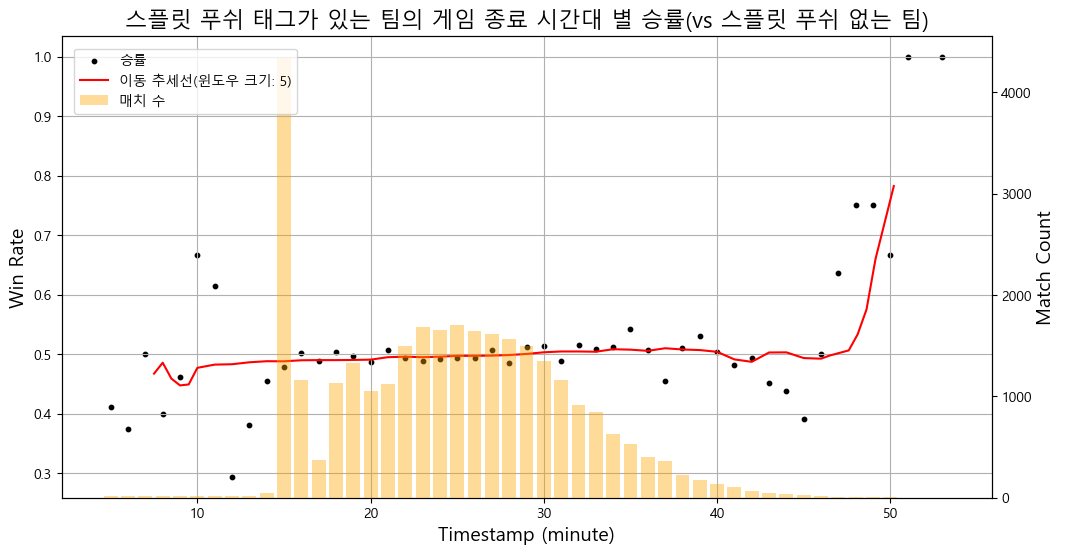

In [205]:
window_size = 5
avg_x, avg_y = moving_average_rate(sp_winrate['ts'], sp_winrate['win_rate'], sp_winrate['match_count'], window_size=window_size)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_ylabel('Win Rate', fontsize=14)
ax1.scatter(sp_winrate['ts'], sp_winrate['win_rate'], color='black', s=10, label='승률')
ax1.plot(avg_x, avg_y, color='red', label=f'이동 추세선(윈도우 크기: {window_size})')
ax1.set_xlabel('Timestamp (minute)', fontsize=14)
ax1.tick_params(axis='y')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.bar(sp_winrate['ts'], sp_winrate['match_count'], label='매치 수', color='orange', alpha=.4)
ax2.set_ylabel('Match Count', fontsize=14)
ax2.grid(False)
ax2.set_axisbelow(False)

plt.title('스플릿 푸쉬 태그가 있는 팀의 게임 종료 시간대 별 승률(vs 스플릿 푸쉬 없는 팀)', fontsize=16)

fig.legend(loc='upper left', bbox_to_anchor=(0.13, 0.87))
plt.show()

#### 스플릿 푸쉬 챔피언의 시간대 별 평균 경험치/골드 획득량 확인

In [211]:
query = '''with cs as (
	select distinct match_id, participant_id, timestamp div 60000 as ts, total_gold, xp
	from champion_stat_per_timestamp
), cpi_tags as (
	select distinct cpi.match_id, cpi.participant_id, if(tags like '%%스플릿 푸쉬%%', 'SP', 'Other') as isSP
	from champion_participant_id cpi left join champion_dict cd on cpi.champion_id = cd.champion_id
	where team_position not in ('JUNGLE', 'BOTTOM', 'UTILITY')
)
select isSP, ts, avg(total_gold) as mean_gold, avg(xp) as mean_xp 
from cs join cpi_tags ct on cs.match_id = ct.match_id and cs.participant_id = ct.participant_id
group by 1, 2;'''

In [213]:
csSP = pd.read_sql(query, engine)
csSP

,isSP,ts,mean_gold,mean_xp
0,Other,0,500.000000,0.000000
1,Other,1,506.464242,0.375956
2,Other,2,600.737435,198.531726
3,Other,3,938.497376,812.774571
4,Other,4,1272.818138,1342.381992
...,...,...,...,...
103,SP,49,21061.673913,25502.695652
104,SP,50,21367.906250,25709.718750
105,SP,51,21079.833333,26033.791667
106,SP,52,22075.538462,27049.153846


In [214]:
csSP = csSP.set_index('isSP')
csSP

,ts,mean_gold,mean_xp
isSP,,,
Other,0,500.000000,0.000000
Other,1,506.464242,0.375956
Other,2,600.737435,198.531726
Other,3,938.497376,812.774571
Other,4,1272.818138,1342.381992
...,...,...,...
SP,49,21061.673913,25502.695652
SP,50,21367.906250,25709.718750
SP,51,21079.833333,26033.791667


Text(0.5, 1.0, '스플릿 푸쉬 챔피언 여부에 따른 골드 획득량 차이')

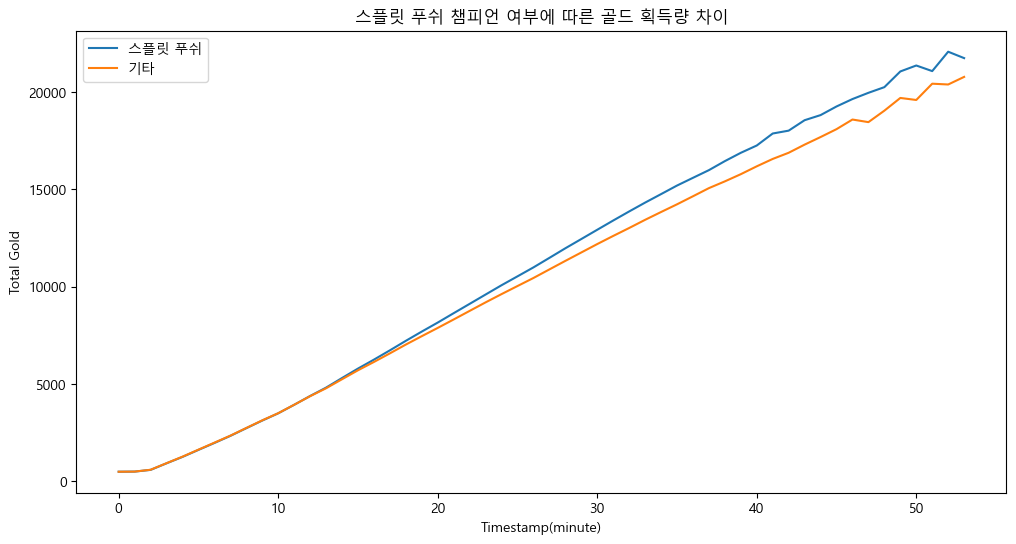

In [215]:
plt.figure(figsize=(12, 6))
plt.plot(csSP.loc['SP', 'ts'], csSP.loc['SP', 'mean_gold'], label='스플릿 푸쉬')
plt.plot(csSP.loc['Other', 'ts'], csSP.loc['Other', 'mean_gold'], label='기타')
plt.legend()
plt.xlabel('Timestamp(minute)')
plt.ylabel('Total Gold')
plt.title('스플릿 푸쉬 챔피언 여부에 따른 골드 획득량 차이')

Text(0.5, 1.0, '스플릿 푸쉬 챔피언 여부에 따른 경험치 획득량 차이')

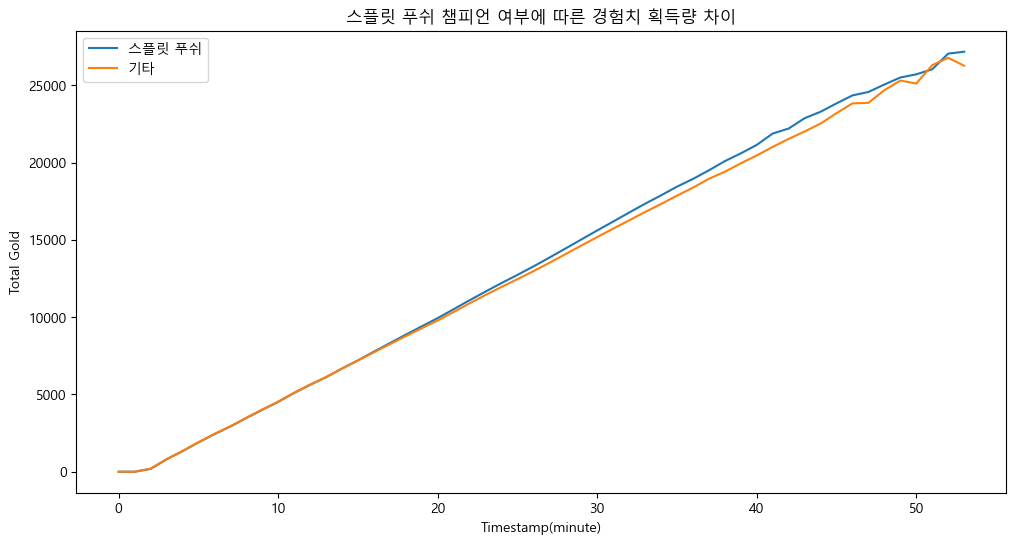

In [216]:
plt.figure(figsize=(12, 6))
plt.plot(csSP.loc['SP', 'ts'], csSP.loc['SP', 'mean_xp'], label='스플릿 푸쉬')
plt.plot(csSP.loc['Other', 'ts'], csSP.loc['Other', 'mean_xp'], label='기타')
plt.legend()
plt.xlabel('Timestamp(minute)')
plt.ylabel('Total Gold')
plt.title('스플릿 푸쉬 챔피언 여부에 따른 경험치 획득량 차이')